In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
dataset = pd.read_csv(r"C:\Users\91958\Desktop\Machine Learning\datasets\insurance.csv")

dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
print("Dataset Shape :", dataset.shape)

Dataset Shape : (1338, 7)


In [7]:
X = dataset.drop("charges", axis=1)
y = dataset["charges"]

print(X.head())
print(y.head())

   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [8]:
X = pd.get_dummies(X, drop_first=True)

print(X.head())

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (1070, 8)
Testing Set : (268, 8)


In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

Ridge()

In [12]:
y_pred = ridge_model.predict(X_test)

print(y_pred[:10])

[ 8971.92398524  7073.34230054 36833.99117804  9459.05708554
 26960.13603638 10867.25311901   181.56953724 16899.75722576
  1101.82745503 11221.03994558]


In [13]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,9095.06825,8971.923985
1,5272.17580,7073.342301
2,29330.98315,36833.991178
3,9301.89355,9459.057086
4,33750.29180,26960.136036
5,4536.25900,10867.253119
6,2117.33885,181.569537
7,14210.53595,16899.757226
8,3732.62510,1101.827455
9,10264.44210,11221.039946


In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 4182.7965965832645
Mean Squared Error (MSE): 33604973.539963305
Root Mean Squared Error (RMSE): 5796.979691180857
R² Score: 0.7835410749121386


In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_
})

coefficients

,Feature,Coefficient
0,age,3611.354521
1,bmi,2034.362351
2,children,516.761658
3,sex_male,-8.615975
4,smoker_yes,9549.276683
5,region_northwest,-157.633519
6,region_southeast,-288.545534
7,region_southwest,-348.270354


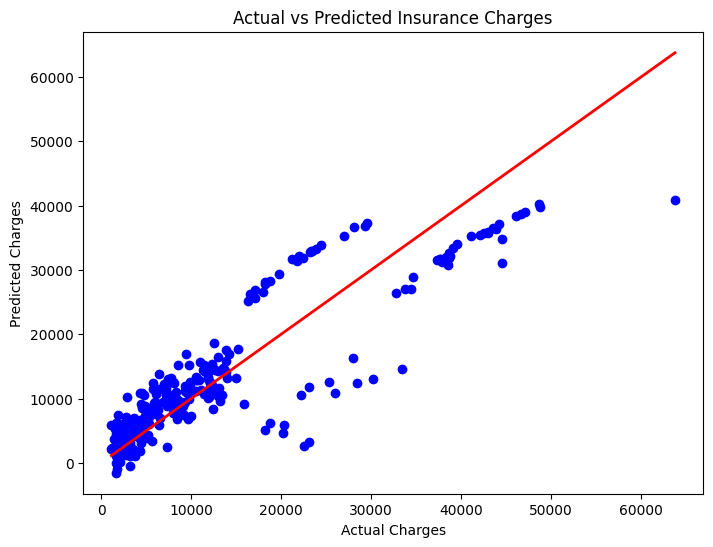

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.show()

In [17]:
alpha_values = [0.01, 0.1, 1, 10, 100]

for alpha in alpha_values:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    score = r2_score(y_test, predictions)

    print(f"Alpha = {alpha}  -->  R² Score = {score:.4f}")

Alpha = 0.01  -->  R² Score = 0.7836
Alpha = 0.1  -->  R² Score = 0.7836
Alpha = 1  -->  R² Score = 0.7835
Alpha = 10  -->  R² Score = 0.7830
Alpha = 100  -->  R² Score = 0.7734


In [18]:
sample_customer = pd.DataFrame([{
    "age": 30,
    "bmi": 25.5,
    "children": 2,
    "sex_male": 1,
    "smoker_yes": 0,
    "region_northwest": 0,
    "region_southeast": 1,
    "region_southwest": 0
}])

sample_customer = sample_customer.reindex(columns=X.columns, fill_value=0)

sample_customer_scaled = scaler.transform(sample_customer)

predicted_charge = ridge_model.predict(sample_customer_scaled)

print("Predicted Insurance Charge: $", round(predicted_charge[0], 2))

Predicted Insurance Charge: $ 4559.16
